In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys 
import os
sys.path.append('..')
import gc

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import time

In [4]:
UPSAMPLE_LATER = True 
UPSAMPLE_RATIO = 0.4
RETRAIN_KNN = True

KNN_1 = True
KNN_2 = True

USING_SMOTE = True

In [5]:
from utils.check_feature import power_scaler_col

In [6]:
appl_train = pd.read_csv('../data/dseb63_application_train.csv', index_col=0)

# ====== BUREAU ======

bureau = pd.read_parquet('../data/dseb63_bureau_general_v2.parquet')
bureau_columns = bureau.columns

new_bureau_columns = {col: 'BUREAU_' + col for col in bureau_columns if col != 'SK_ID_CURR'} 
bureau.rename(columns=new_bureau_columns, inplace=True)

# ====== PREVIOUS APPLICATION ======

prev_app = pd.read_parquet('../data/prev_app_hanh.parquet')
prev_app_columns = prev_app.columns

new_prev_app_columns = {col: 'PREV_APP_' + col for col in prev_app_columns if col != 'SK_ID_CURR'}
prev_app.rename(columns=new_prev_app_columns, inplace=True)

# ====== INSTALLMENTS PAYMENTS ======

installments = pd.read_csv('../data/dseb63_installment_gb.csv', index_col=0)
installments_columns = installments.columns

installments.drop(columns= [col for col in installments_columns if 'TARGET' in col], inplace=True)

new_installments_columns = {col: 'INSTALLMENTS_' + col for col in installments_columns if col != 'SK_ID_CURR'}
installments.rename(columns=new_installments_columns, inplace=True)

# ====== CREDIT CARD BALANCE ======

credit_card = pd.read_parquet('../data/dseb63_credit_card_balance_gb.parquet')
credit_card_columns = credit_card.columns

new_credit_card_columns = {col: 'CREDIT_CARD_' + col for col in credit_card_columns if col != 'SK_ID_CURR'}
credit_card.rename(columns=new_credit_card_columns, inplace=True)

# ====== POS CASH BALANCE ======

pos_cash = pd.read_csv('../data/dseb63_pos_cash_gb.csv', index_col=0)
pos_cash_columns = pos_cash.columns

new_posh_cash_columns = {col: 'POS_CASH_' + col for col in pos_cash_columns if col != 'SK_ID_CURR'}
pos_cash.rename(columns=new_posh_cash_columns, inplace=True)


# ====== MERGE DATA ======

df = appl_train.merge(bureau, on='SK_ID_CURR', how='left')
df = df.merge(installments, on='SK_ID_CURR', how='left')
df = df.merge(pos_cash, on='SK_ID_CURR', how='left')
df = df.merge(credit_card, on='SK_ID_CURR', how='left')
df = df.merge(prev_app, on='SK_ID_CURR', how='left')


In [7]:
df['HOUSETYPE_MODE'].value_counts()

HOUSETYPE_MODE
block of flats      120320
specific housing      1193
terraced house         956
Name: count, dtype: int64

<Axes: >

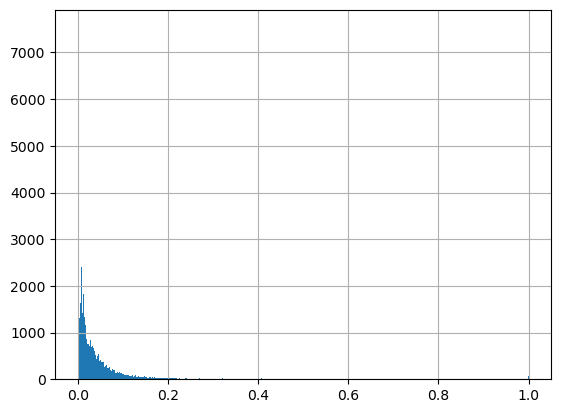

In [8]:
df['COMMONAREA_AVG'].hist(bins=1000)

In [9]:
def RELU(series):
    return series.apply(lambda x: max(0, x))
    

In [10]:
def process_df(df):
    df = df.copy()
    
    df['EMERGENCYSTATE_MODE'].fillna('No', inplace=True)
    df['FONDKAPREMONT_MODE'].fillna('Unknown', inplace=True)
    df['WALLSMATERIAL_MODE'].fillna('Not Specified', inplace=True)
    df['OCCUPATION_TYPE'].replace('IT staff', 'High skill tech staff', inplace=True)
    df['OCCUPATION_TYPE'].replace('Realty agents', 'Sales staff', inplace=True)
    df['OCCUPATION_TYPE'].replace('HR staff', 'Laborers', inplace=True)
    df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)
    df['OCCUPATION_TYPE'].replace(['Cleaning staff', 'Cooking staff', 'Waiters/barmen staff'], 'F&B staff', inplace=True)
    

    df['ORGANIZATION_TYPE'].replace('XNA', 'Unknown', inplace=True)
    df['HOUSETYPE_MODE'].replace(['block of flats', 'specific housing'], 'house', inplace=True)
    
    df['WALLSMATERIAL_MODE'].replace(['Others', 'Mixed', 'Monolithic'], 'Others', inplace=True)
    df['WALLSMATERIAL_MODE'].replace(['Block', 'Stone, brick'], 'Brick', inplace=True)

    map_week_day = {
    'MONDAY': 1,
    'TUESDAY': 2,
    'WEDNESDAY': 3,
    'THURSDAY': 4,
    'FRIDAY': 5,
    'SATURDAY': 6,
    'SUNDAY': 7
    }

    df['WEEKDAY_APPR_PROCESS_START'] = df['WEEKDAY_APPR_PROCESS_START'].map(map_week_day)

    map_edu = {
        'Lower secondary': 0,
        'Secondary / secondary special': 1,
        'Incomplete higher': 2,
        'Higher education': 3,
        'Academic degree': 5
    }

    df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(map_edu, na_action='ignore').astype(int).fillna(0)

    df['NAME_FAMILY_STATUS'].replace('Unknown', 'Single / not married', inplace=True)
    df['CODE_GENDER'].replace('XNA', 'F', inplace=True)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(365243)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(0, 365243)

    others = df['NAME_INCOME_TYPE'].value_counts().index[4:]
    df['NAME_INCOME_TYPE'].replace(others, 'Others', inplace=True)
    df['NAME_TYPE_SUITE'].fillna('Unaccompanied', inplace=True)

    df['OWN_CAR_AGE'].fillna(-100, inplace=True)
    df['TOTALAREA_MODE'].fillna(0, inplace=True)
    
    df['AGE_INT'] = -df['DAYS_BIRTH'] // 365
    # Steal code
    
    def group_organizations(org_type):
        if 'Trade' in org_type:
            return 'Trade'
        elif 'Industry' in org_type:
            return 'Industry'
        elif 'Business' in org_type:
            return 'Business Entity'
        elif 'Transport' in org_type:
            return 'Transport'
        elif 'University' in org_type:
            return 'School'
        elif org_type in ['Police', 'Electricity', 'Culture', 'Religion', 'Telecom', 'Emergency', 'Mobile', 'Postal']:
            return 'Public Sector'

        else:
            return org_type
    
    df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(group_organizations)
    df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].replace(['Other_A', 'Other_B'], 'Other')
    
    med_income = df.groupby(['ORGANIZATION_TYPE', 'NAME_EDUCATION_TYPE'])['AMT_INCOME_TOTAL'].transform('median')
    med_income2 = df.groupby('ORGANIZATION_TYPE')['AMT_INCOME_TOTAL'].transform('median')
    df['income_ratio'] = df['AMT_INCOME_TOTAL'] / med_income
    df['income_ratio2'] = df['AMT_INCOME_TOTAL'] / med_income2
    df['true_annuity_div_income'] = df['AMT_ANNUITY'] / med_income
    df['true_annuity_div_income2'] = df['AMT_ANNUITY'] / med_income2
    df['true_income_div_totalarea'] = med_income / df['TOTALAREA_MODE'].clip(0.001,1)
    df['true_income_div_totalarea2'] = med_income2 / df['TOTALAREA_MODE'].clip(0.001,1)
    
    df['annuity_income_percentage'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['car_to_birth_ratio'] = RELU(df['OWN_CAR_AGE'] / df['DAYS_BIRTH'])
    df['car_to_employ_ratio'] = RELU(df['OWN_CAR_AGE'] / df['DAYS_EMPLOYED'])
    df['children_ratio'] = df['CNT_CHILDREN'] / df['CNT_FAM_MEMBERS']
    df['credit_to_annuity_ratio'] = df['AMT_CREDIT'] / df['AMT_ANNUITY'] # check
    df['credit_to_goods_ratio'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
    df['credit_to_income_ratio'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    
    
    df['ext_sources_mean'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['ext_sources_sum'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].sum(axis=1)
    df['ext_sources_var'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].var(axis=1)
    df['ext_sources_weighted'] = df.EXT_SOURCE_1 * 2 + df.EXT_SOURCE_2 * 3 + df.EXT_SOURCE_3 * 4
    df['EXT_SOURCE_MISSING_VALUES'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isna().sum(axis=1)
    
    df['income_credit_percentage'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['income_per_child'] = df['AMT_INCOME_TOTAL'] / (1 + df['CNT_CHILDREN'])
    df['income_per_person'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    df['phone_to_birth_ratio'] = RELU(df['DAYS_LAST_PHONE_CHANGE'] / df['DAYS_BIRTH'])
    df['phone_to_employ_ratio'] = RELU(df['DAYS_LAST_PHONE_CHANGE'] / (df['DAYS_EMPLOYED'] + 1e-5)) * (df['DAYS_EMPLOYED'] < 0) 
    

    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['DEBT_BURDEN_PER_WORKING_DAY'] = df['PAYMENT_RATE'] / (df['DAYS_EMPLOYED'] + 1e-5) * (df['DAYS_EMPLOYED'] < 0) 
    df['DEBT_BURDEN_PER_LIFE_DAY'] = df['PAYMENT_RATE'] / df['DAYS_BIRTH']
    df['CREDIT_GOODS_PRICE_RATIO1'] = (df['AMT_CREDIT'] - df['AMT_GOODS_PRICE']) /  df['AMT_GOODS_PRICE']
    df['CREDIT_GOODS_PRICE_RATIO2'] = (df['AMT_CREDIT'] - df['AMT_GOODS_PRICE']) /  df['AMT_CREDIT']
    df['CREDIT_DOWN_PAYMENT'] = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']

    df['sin_HOUR_APPR_PROCESS_START'] = np.sin(2 * np.pi * df['HOUR_APPR_PROCESS_START'] / 24)
    df['cos_HOUR_APPR_PROCESS_START'] = np.cos(2 * np.pi * df['HOUR_APPR_PROCESS_START'] / 24)
    df.drop(columns=['HOUR_APPR_PROCESS_START'], inplace=True)

    docs = [f for f in df.columns if 'FLAG_DOC' in f]
    df['NEW_DOC_IND_AVG'] = df[docs].mean(axis=1)
    df['NEW_DOC_IND_STD'] = df[docs].std(axis=1)
    df['NEW_DOC_IND_KURT'] = df[docs].kurtosis(axis=1)
    df['HAS_DOCUMENT'] = df[docs].max(axis=1)
    df['DOCUMENT_COUNT'] = df[docs].sum(axis=1)

    #Drop flag document  
    flag_document = [f for f in df.columns if 'FLAG_DOCUMENT_' in f]
    df.drop(columns=flag_document, inplace=True)
    
    df['LIVINGAREA_AVG'] = df['LIVINGAREA_AVG'].fillna(0)
    df['LANDAREA_AVG'] = df['LANDAREA_AVG'].fillna(0)
    df['FLOORSMAX_AVG'] = df['FLOORSMAX_AVG'].fillna(0)
    df['LIVINGAPARTMENTS_AVG'] = df['LIVINGAPARTMENTS_AVG'].fillna(0)
    df['YEARS_BUILD_AVG'] = df['YEARS_BUILD_AVG'].fillna(0)

    df['RATIO_AMT_GOODS_PRICE_TO_LIVINGAREA_AVG'] = (df['AMT_GOODS_PRICE'] / df['LIVINGAREA_AVG'].clip(0.05,1) +1e-5) * (df['LIVINGAREA_AVG'] / df['LIVINGAREA_AVG']+1e-5)
    df['RATIO_AMT_GOODS_PRICE_TO_LANDAREA_AVG'] = (df['AMT_GOODS_PRICE'] / df['LANDAREA_AVG'].clip(0.05,1) +1e-5) * (df['LANDAREA_AVG'] / df['LANDAREA_AVG']+1e-5)
    df['RATIO_AMT_GOODS_PRICE_TO_FLOORSMAX_AVG_AVG'] = (df['AMT_GOODS_PRICE'] / df['FLOORSMAX_AVG'].clip(0.05,1) +1e-5) * (df['FLOORSMAX_AVG'] / df['FLOORSMAX_AVG']+1e-5)
    df['RATIO_AMT_GOODS_PRICE_TO_LIVINGAPARTMENTS_AVG'] = (df['AMT_GOODS_PRICE'] / df['LIVINGAPARTMENTS_AVG'].clip(0.05,1) +1e-5) * (df['LIVINGAPARTMENTS_AVG'] / df['LIVINGAPARTMENTS_AVG']+1e-5)
    df['RATIO_AMT_GOODS_PRICE_TO_YEARS_BUILD_AVG'] = (df['AMT_GOODS_PRICE'] / df['YEARS_BUILD_AVG'].clip(0.05,1) +1e-5) * (df['YEARS_BUILD_AVG'] / df['YEARS_BUILD_AVG']+1e-5)
    
    
    df['RELIABILITY_IN_CUSTOMER_CITY'] = df['REG_CITY_NOT_LIVE_CITY'] + df['REG_CITY_NOT_WORK_CITY'] + df['REG_REGION_NOT_LIVE_REGION'] + df['REG_REGION_NOT_WORK_REGION'] + df['LIVE_CITY_NOT_WORK_CITY'] + df['LIVE_REGION_NOT_WORK_REGION']
    df['SUM_CONTACTS'] = df['FLAG_MOBIL'] + df['FLAG_EMP_PHONE'] + df['FLAG_WORK_PHONE'] + df['FLAG_CONT_MOBILE'] + df['FLAG_PHONE'] + df['FLAG_EMAIL']

    #Some features from bureau 
    df['TOTAL_ENQUIRIES_CREDIT_BUREAU'] = df[['AMT_REQ_CREDIT_BUREAU_DAY',
                                            'AMT_REQ_CREDIT_BUREAU_HOUR',
                                            'AMT_REQ_CREDIT_BUREAU_WEEK',
                                            'AMT_REQ_CREDIT_BUREAU_MON',
                                            'AMT_REQ_CREDIT_BUREAU_QRT',
                                            'AMT_REQ_CREDIT_BUREAU_YEAR']].sum(axis=1)
    
    
        
    # df['PCTG_ENQUIRIES_HOUR'] = df['AMT_REQ_CREDIT_BUREAU_HOUR'] / df['TOTAL_ENQUIRIES_CREDIT_BUREAU']
    # df['PCTG_ENQUIRIES_DAY'] = df['AMT_REQ_CREDIT_BUREAU_DAY'] / df['TOTAL_ENQUIRIES_CREDIT_BUREAU']
    df['PCTG_ENQUIRIES_WEEK'] = df['AMT_REQ_CREDIT_BUREAU_WEEK'] / df['TOTAL_ENQUIRIES_CREDIT_BUREAU']
    df['PCTG_ENQUIRIES_MON'] = df['AMT_REQ_CREDIT_BUREAU_MON'] / df['TOTAL_ENQUIRIES_CREDIT_BUREAU']
    df['PCTG_ENQUIRIES_QRT'] = df['AMT_REQ_CREDIT_BUREAU_QRT'] / df['TOTAL_ENQUIRIES_CREDIT_BUREAU']
    df['PCTG_ENQUIRIES_YEAR'] = df['AMT_REQ_CREDIT_BUREAU_YEAR'] / df['TOTAL_ENQUIRIES_CREDIT_BUREAU']

    df.drop(columns=['AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_WEEK'], inplace=True)

    missing_columns = ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
                   'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
                   'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
                   'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG']

    df['MISSING_GRADINGS'] = df[missing_columns].isna().sum(axis=1)
    # Reliability in customer city or region of residence
    df['RELIABILITY_IN_CUSTOMER_CITY'] = df['REG_CITY_NOT_LIVE_CITY'] + df['REG_CITY_NOT_WORK_CITY'] + df['REG_REGION_NOT_LIVE_REGION'] + df['REG_REGION_NOT_WORK_REGION'] + df['LIVE_CITY_NOT_WORK_CITY'] + df['LIVE_REGION_NOT_WORK_REGION']
    df['SUM_CONTACTS'] = df['FLAG_MOBIL'] + df['FLAG_EMP_PHONE'] + df['FLAG_WORK_PHONE'] + df['FLAG_CONT_MOBILE'] + df['FLAG_PHONE'] + df['FLAG_EMAIL']

    # numerical transformation
    df['DAYS_EMPLOYED'].replace(365243,0, inplace=True)
    df['days_employed_percentage'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    
    
    df['REGION_POPULATION_RELATIVE'] = np.sqrt(df['REGION_POPULATION_RELATIVE'])
    df['APARTMENTS_AVG'] = np.log1p(50 * df['APARTMENTS_AVG'])
    df['YEARS_BUILD_AVG'] = df['YEARS_BUILD_AVG'] ** 3
    df['COMMONAREA_AVG'] = df['COMMONAREA_AVG'].clip(0.0001,1) ** (-1/5)
    df['ELEVATORS_AVG'] = df['ELEVATORS_AVG'] ** (1/10)
    df['ENTRANCES_AVG'] = df['ENTRANCES_AVG'] ** (1/3)
    df['FLOORSMAX_AVG'] = df['FLOORSMAX_AVG'] ** (1/2.5)
    df['FLOORSMIN_AVG'] = df['FLOORSMIN_AVG'] ** (1/2.2)
    df['LANDAREA_AVG'] = df['LANDAREA_AVG'] ** (1/5)
    df['LIVINGAPARTMENTS_AVG'] = df['LIVINGAPARTMENTS_AVG'] ** (1/3)
    df['LIVINGAREA_AVG'] = df['LIVINGAREA_AVG'] ** (1/3)
    df['NONLIVINGAPARTMENTS_AVG'] = df['NONLIVINGAPARTMENTS_AVG'] ** (1/5)
    df['NONLIVINGAREA_AVG'] = df['NONLIVINGAREA_AVG'] ** (1/3)
    df['OBS_30_CNT_SOCIAL_CIRCLE'] = df['OBS_30_CNT_SOCIAL_CIRCLE'] ** (1/5)
    df['DEF_30_CNT_SOCIAL_CIRCLE'] = df['DEF_30_CNT_SOCIAL_CIRCLE'] ** (1/5)
    df['OBS_60_CNT_SOCIAL_CIRCLE'] = df['OBS_60_CNT_SOCIAL_CIRCLE'] ** (1/5)
    df['DEF_60_CNT_SOCIAL_CIRCLE'] = df['DEF_60_CNT_SOCIAL_CIRCLE'] ** (1/5)
    
    return df
df = process_df(df)

In [11]:
def display_missing_data_info(dataframe, ascending=False):
    missing_values_count = dataframe.isnull().sum()
    missing_values_percentage = (dataframe.isnull().mean() * 100)
    missing_data = pd.DataFrame({
        'Missing Values': missing_values_count,
        'Percentage (%)': missing_values_percentage
    })
    
    missing_data = missing_data[missing_data['Missing Values'] > 0]
    
    sorted_missing_data = missing_data.sort_values(by='Missing Values', ascending=ascending)

    print(sorted_missing_data)
    return sorted_missing_data

In [12]:
# display_missing_data_info(df)

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, OrdinalEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

In [14]:
df.to_parquet('../data/df_train.parquet', index=False)

In [15]:
X = pd.read_parquet('../data/df_train.parquet')
# X = df

In [16]:
X['TARGET'].value_counts()

TARGET
0    226133
1     19876
Name: count, dtype: int64

In [17]:
y = X['TARGET']
X.drop(columns=['TARGET', 'SK_ID_CURR'], inplace=True)


In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246009 entries, 0 to 246008
Columns: 882 entries, NAME_CONTRACT_TYPE to days_employed_percentage
dtypes: float64(841), int64(27), object(14)
memory usage: 1.6+ GB


In [19]:
ordinal_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE', 'CODE_GENDER', 'NAME_CONTRACT_TYPE']
float_cols = []
int_cols = []
cate_cols = []
flag_cols = []
for col in X.columns:
    if col not in ordinal_cols:
        if X[col].dtype == 'float64':
            float_cols.append(col)
        elif X[col].dtype == 'int64':

            int_cols.append(col)
        else:
            cate_cols.append(col)


Find suitable column for power transformation

In [20]:
power_col, standard_col, min_max_col = power_scaler_col(X[float_cols+int_cols])

100%|██████████| 868/868 [00:24<00:00, 35.24it/s]


In [21]:
len(power_col), len(standard_col), len(min_max_col)

(438, 293, 137)

In [22]:
X[float_cols+int_cols].clip(-999999999, 999999999, inplace=True)

In [23]:
description = X.describe()

In [24]:
description.columns[description.values[-1,:] > 999999998]

Index(['BUREAU_GENERAL_AMT_CREDIT_SUM_sum', 'BUREAU_SUM_CONSUMER_CREDIT',
       'BUREAU_CLOSE_AMT_CREDIT_SUM'],
      dtype='object')

In [25]:
for col in float_cols:
    X[col].fillna(0, inplace=True)
    
for col in int_cols:
    X[col].fillna(0, inplace=True)
for col in cate_cols:
    X[col].fillna('Unknown', inplace=True)

In [26]:
X_columns = X.columns

In [27]:
from sklearn.model_selection import train_test_split

X_train_, X_val_, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

### ADD KNN Feature

In [28]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=500, n_jobs=-1))  
])

knn_pipeline_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=500, n_jobs=-1))  
])

In [29]:
y = y.to_numpy()
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()

In [30]:
onehot_transformer = OneHotEncoder(handle_unknown='ignore')
power_transformer = PowerTransformer()
ordinal_transformer = OrdinalEncoder()
scaler_transformer = StandardScaler()
min_max_transformer = MinMaxScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', onehot_transformer, cate_cols),
        ('power', power_transformer, power_col), # power_transformer
        ('ordinal', ordinal_transformer, ordinal_cols),
        ('scale', scaler_transformer, standard_col),
        ('min_max', min_max_transformer, min_max_col)
        
    ]
)


In [31]:
weak_df_col = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'credit_to_annuity_ratio', 'annuity_income_percentage']
weak_df_col_2 = ['DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'days_employed_percentage', 'car_to_birth_ratio', 'NAME_EDUCATION_TYPE', 'AGE_INT']

## Upsample - Downsample

### Manual double

In [32]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

smote = SMOTE(sampling_strategy=UPSAMPLE_RATIO, random_state=42, k_neighbors=10)



In [35]:
def resample_data(X_train, y_train, rate = 0.2):
    if USING_SMOTE:
        return smote.fit_resample(X_train, y_train)
    else:
        posidx = (y_train == 1)
        negidx = (y_train == 0)

        # X_train = np.concatenate([X_train, y_train2], axis=1)
        posidx = np.where(posidx)[0]
        # train_data_pos = X_train[posidx]
        # train_data_neg = X_train[negidx]

        posidx2 = resample(posidx, n_samples=int(len(negidx) * rate), random_state=42)

        idx = np.concatenate([posidx2, np.where(negidx)[0]])

        if isinstance(X_train, pd.DataFrame):
            return X_train.iloc[idx,:], y_train[idx]
        else:
            return X_train[idx,:], y_train[idx]

In [36]:
X_resampled_, y_resampled = resample_data(X_train_, y_train, rate=UPSAMPLE_RATIO)

In [37]:
X_resampled_.to_parquet('../temp/X_resampled.parquet', index=False)

In [38]:
# Transform + KNN before upsample
if UPSAMPLE_LATER:

    print('Fit weak features')
    start = time.time()
    knn_pipeline.fit(X_train_[weak_df_col], y_train) # fit on original data
    knn_pipeline_2.fit(X_train_[weak_df_col_2], y_train) # fit on original data


    weak_feature_train = knn_pipeline.predict_proba(X_resampled_[weak_df_col])[:,1]
    weak_feature_val = knn_pipeline.predict_proba(X_val_[weak_df_col])[:,1]

    weak_feature_train_2 = knn_pipeline_2.predict_proba(X_resampled_[weak_df_col_2])[:,1]
    weak_feature_val_2 = knn_pipeline_2.predict_proba(X_val_[weak_df_col_2])[:,1]

    end = time.time()
    print('Weak features fitted', end-start)

    print('Transforming data')
    start = time.time()
    preprocessor.fit(X_train_) # fit on original data

    X_resampled = preprocessor.transform(X_resampled_)
    X_val = preprocessor.transform(X_val_)
    end = time.time()
    print('Data transformed', end-start)


    X_resampled = np.concatenate([X_resampled, weak_feature_train.reshape(-1,1), weak_feature_train_2.reshape(-1,1)], axis=1)
    X_val = np.concatenate([X_val, weak_feature_val.reshape(-1,1), weak_feature_val_2.reshape(-1,1)], axis=1)

Fit weak features
Weak features fitted 62.10079264640808
Transforming data
Data transformed 45.63751935958862


In [39]:
X_resampled.shape

(292083, 951)

In [40]:
# Transform + KNN after upsample
if not UPSAMPLE_LATER:
    

    print('Fit weak features')
    start = time.time()
    knn_pipeline.fit(X_resampled_[weak_df_col], y_resampled)
    
    weak_feature_train = knn_pipeline.predict_proba(X_resampled_[weak_df_col])[:,1]
    weak_feature_val = knn_pipeline.predict_proba(X_val_[weak_df_col])[:,1]

    weak_feature_train_2 = knn_pipeline_2.predict_proba(X_resampled_[weak_df_col_2])[:,1]
    weak_feature_val_2 = knn_pipeline_2.predict_proba(X_val_[weak_df_col_2])[:,1]
    end = time.time()
    print('Weak features fitted', end-start)

    print('Transform features')
    start = time.time()
    X_resampled = preprocessor.fit_transform(X_resampled_)
    X_val = preprocessor.transform(X_val_)
    end = time.time()
    print('Transform fitted', end-start)

    X_resampled = np.concatenate([X_resampled, weak_feature_train.reshape(-1,1), weak_feature_train_2.reshape(-1,1)], axis=1)
    X_val = np.concatenate([X_val, weak_feature_val.reshape(-1,1), weak_feature_val_2.reshape(-1,1)], axis=1)

In [41]:
X_resampled.shape

(292083, 951)

In [42]:
cat_feature = preprocessor.named_transformers_['onehot'].get_feature_names_out(cate_cols)
feature_names = np.concatenate([cat_feature, power_col, ordinal_cols, standard_col, min_max_col, ['WEAK_FEATURE', 'WEAK_FEATURE_2']])
mask_weak_df_col = np.nonzero(np.isin(feature_names, np.array(weak_df_col)))[0]

In [71]:
X_resampled = pd.DataFrame(X_resampled, columns=feature_names)
X_val = pd.DataFrame(X_val, columns=feature_names)

X_resampled['TARGET'] = y_resampled
X_val['TARGET'] = y_val

X_resampled.to_parquet('../temp/X_resampled.parquet', index=False)
X_val.to_parquet('../temp/X_val.parquet', index=False)

In [44]:
del X_resampled_
del X_train_

In [45]:
# X_resampled = X_train
# y_resampled = y_train

### Feature name col

In [46]:

from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [47]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

In [48]:
pca = PCA()
pca.fit(X_resampled)

PCA()

In [49]:
explained_variance = pca.explained_variance_ratio_

# Get the absolute values of PCA components (loadings)
feature_contributions = np.abs(pca.components_)

# Aggregate feature importance scores
# Weight each feature's contribution by the variance explained by the component
weighted_contributions = feature_contributions * explained_variance[:, np.newaxis]

# Sum weighted contributions across components
feature_importance = weighted_contributions.sum(axis=0)

# Create a DataFrame for ranking
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)
importance_df.reset_index(drop=True, inplace=True)

In [50]:
importance_df

,Feature,Importance
0,PREV_APP_PREV_NAME_CONTRACT_STATUS_Refused_SUM,3.178247e-02
1,PREV_APP_PREV_ANNUITY_PAYMENT_PRODUCT_STD,3.168828e-02
2,PREV_APP_PREV_NAME_CONTRACT_STATUS_Canceled_SUM,3.123665e-02
3,PREV_APP_PREV_AMT_CREDIT_STD,3.115133e-02
4,PREV_APP_REFUSED_CNT_PAYMENT_MEAN,3.114594e-02
...,...,...
946,POS_CASH_NOT_COMPLETED_SHORT_CNT_INSTALMENT,1.621329e-22
947,PREV_APP_APPROVED_NAME_CONTRACT_STATUS_Unused ...,1.373731e-33
948,PREV_APP_APPROVED_NAME_CONTRACT_STATUS_Cancele...,1.353059e-33
949,PREV_APP_APPROVED_NAME_CONTRACT_TYPE_XNA_SUM,1.308143e-33


In [51]:
def select_features_with_pca(X):
    """
    Select features contributing to principal components above a certain threshold.

    Parameters:
    X (numpy array or pandas DataFrame): Input feature matrix.
    threshold (float): Contribution threshold for selecting features (default is 0.1).

    Returns:
    selected_columns (list): List of selected feature names or indices.
    selected_data (DataFrame): Data with selected features.
    """
    # Convert to DataFrame if X is a NumPy array
    # if isinstance(X, np.ndarray):
    #     X = pd.DataFrame(X, columns=[f"Feature{i+1}" for i in range(X.shape[1])])
    
    # Apply PCA
    pca = PCA()
    pca.fit(X)
    
    # Calculate absolute loadings (contributions of features to components)
    explained_variance = pca.explained_variance_ratio_
    feature_contributions = np.abs(pca.components_)
    weighted_contributions = feature_contributions * explained_variance[:, np.newaxis]
    # Identify features exceeding the threshold for any component
    
    feature_importance = weighted_contributions.sum(axis=0)
    
    # Filter the data to keep only selected features
    # selected_data = X[feature_mask, :]
    
    return feature_importance

IF USING PCA

In [52]:
feature_importance = select_features_with_pca(X_resampled)

In [67]:
feature_map = (feature_importance > 0.0001)

In [68]:
# feature_map = np.ones(len(feature_names), dtype=bool)

In [69]:
feature_map.sum()

920

# Modelling

In [56]:
from sklearn.preprocessing import KBinsDiscretizer

def adaptive_kbins(X, max_bins=100):
    bin_pipeline = ColumnTransformer([])
    for col in range(X.shape[1]):
        unique_values = np.unique(X[:, col])
        
        num_bin = max(min(max_bins, 2 * int(np.sqrt(len(unique_values))) + 1, len(unique_values)),2)
        bin_pipeline.transformers.append((f'bin_{col}', KBinsDiscretizer(n_bins=num_bin, encode='ordinal', strategy='quantile'), [col]))

    return bin_pipeline



In [57]:
discretizer = adaptive_kbins(X_resampled, max_bins=100)
X_train_discretized = discretizer.fit_transform(X_resampled)
X_val_discretized = discretizer.transform(X_val)

In [58]:
logistic_model = LogisticRegression(random_state=42, max_iter=10000, class_weight='balanced')

In [59]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=8, class_weight = 'balanced', min_samples_split=200, min_samples_leaf=500, criterion='entropy')

In [60]:

# dt_pipeline = Pipeline([
#     ('binning', adaptive_kbins(X_resampled, max_bins=100)),
#     ('clf', dt_model)
# ])

dt_pipeline = Pipeline([
    ('binning', KBinsDiscretizer(n_bins=100, encode='ordinal', strategy='quantile')),
    ('clf', dt_model)
])

In [61]:
stacking_model = StackingClassifier(
    estimators=[
        ('lr', logistic_model),
        ('dt', dt_pipeline)
    ],
    final_estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=10000),  # Final model for stacking
    cv=5,
    n_jobs=-1
)

In [62]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [63]:
from sklearn.metrics import make_scorer, roc_auc_score
def gini_coefficient(y_true, y_pred):
    """
    Calculate the Gini coefficient using predictions and true labels.
    
    Parameters:
    y_true (array-like): True binary labels.
    y_pred (array-like): Predicted probabilities.
    
    Returns:
    float: Gini coefficient.
    """
    auc = roc_auc_score(y_true, y_pred)  # AUC calculation
    return 2 * auc - 1  # Gini coefficient

In [64]:
gini_scorer = make_scorer(gini_coefficient, needs_proba=True)

In [70]:
print("Logistic Regression Cross-Validation Scores:")
results = cross_validate(logistic_model, X_resampled[:, feature_map], y_resampled, cv=kfold, scoring=gini_scorer, n_jobs=-1,return_estimator=True)

for i, estimator in enumerate(results['estimator']):
    y_pred = estimator.predict_proba(X_val[:, feature_map])
    gini_scores = gini_coefficient(y_val, y_pred[:,1])
    print(f"- Gini Score for fold {i}: {gini_scores:.4f}")

Logistic Regression Cross-Validation Scores:
- Gini Score for fold 0: 0.5566
- Gini Score for fold 1: 0.5589
- Gini Score for fold 2: 0.5581
- Gini Score for fold 3: 0.5554
- Gini Score for fold 4: 0.5571


In [66]:
raise ValueError('Stop here')

ValueError: Stop here

### Transform first

Logistic Regression Cross-Validation Scores:
- Gini Score for fold 0: 0.5553
- Gini Score for fold 1: 0.5581
- Gini Score for fold 2: 0.5570
- Gini Score for fold 3: 0.5543
- Gini Score for fold 4: 0.5564

Logistic Regression Cross-Validation Scores:
- Gini Score for fold 0: 0.5531
- Gini Score for fold 1: 0.5532
- Gini Score for fold 2: 0.5542
- Gini Score for fold 3: 0.5553
- Gini Score for fold 4: 0.5532

In [ ]:
# print("Decision Tree Cross-Validation Scores:")
# results = cross_validate(dt_model, X_train_discretized[:, feature_map], y_resampled, cv=kfold, scoring=gini_scorer, n_jobs=-1,return_estimator=True)

# for i, estimator in enumerate(results['estimator']):
#     y_pred = estimator.predict_proba(X_val_discretized[:, feature_map])
#     gini_scores = gini_coefficient(y_val, y_pred[:,1])
#     print(f"Gini Score for fold {i}: {gini_scores:.4f}")


print("Decision Tree Cross-Validation Scores:")
results = cross_validate(dt_pipeline, X_resampled[:, feature_map], y_resampled, cv=kfold, scoring=gini_scorer, n_jobs=-1,return_estimator=True)

for i, estimator in enumerate(results['estimator']):
    y_pred = estimator.predict_proba(X_val_discretized[:, feature_map])
    gini_scores = gini_coefficient(y_val, y_pred[:,1])
    print(f"Gini Score for fold {i}: {gini_scores:.4f}")    

Decision Tree Cross-Validation Scores:


/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qu

Gini Score for fold 0: 0.1407
Gini Score for fold 1: 0.0731
Gini Score for fold 2: 0.1069
Gini Score for fold 3: 0.0819
Gini Score for fold 4: 0.0378


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [ ]:
param_dist = {
    'criterion': [ 'entropy', 'log_loss'],  # Splitting criteria
    'max_depth': [8, 10, 12],  # Maximum tree depth
    'min_samples_split': [200, 500, 1000, 2000],  # Minimum samples to split a node
    'min_samples_leaf': [500, 1000, 2000],  # Minimum samples at a leaf node
}

random_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_dist,
    n_iter=40,# Number of combinations to try
    scoring='roc_auc',
    cv=5,  # 5-fold cross-validation
    verbose=1,
    n_jobs=10
)


In [ ]:
# random_search.fit(X_train_discretized[:, feature_map], y_resampled)
# y_pred = random_search.predict_proba(X_val_discretized[:, feature_map])
# gini_scores = gini_coefficient(y_val, y_pred[:,1])
# print(f"Gini Score: {gini_scores:.4f}")

{'min_samples_split': 200, 'min_samples_leaf': 500, 'max_depth': 12, 'criterion': 'entropy'}

In [ ]:
# dt_pipeline = Pipeline([
#     ('binning', adaptive_kbins(X_resampled, max_bins=100)),
#     ('clf', DecisionTreeClassifier(random_state=42, **random_search.best_params_))
# ])

In [ ]:
# stacking_model = StackingClassifier(
#     estimators=[
#         ('lr', logistic_model),
#         ('dt', DecisionTreeClassifier(random_state=42, **random_search.best_params_))
#     ],
#     final_estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=10000),  # Final model for stacking
#     cv=5,
#     n_jobs=-1
# )

In [ ]:
print("Stacking Scores:")
stacking_model.fit(X_resampled[:, feature_map], y_resampled)
y_pred = stacking_model.predict_proba(X_val[:, feature_map])
gini_scores = gini_coefficient(y_val, y_pred[:,1])
print(f"Gini Scores: {gini_scores}")

Stacking Scores:


/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qu

Gini Scores: 0.5493755439371293


Stacking Cross-Validation Scores:


Mean Gini Score: 0.5536432676454963

In [ ]:
X_resampled.shape

(258872, 999)

In [70]:
df_test = pd.read_csv('../data/dseb63_application_test.csv',  index_col=0)
# df_test = pd.read_parquet('../data/df_test.parquet')

In [71]:
df_test = df_test.merge(bureau, on='SK_ID_CURR', how='left')
df_test = df_test.merge(installments, on='SK_ID_CURR', how='left')
df_test = df_test.merge(pos_cash, on='SK_ID_CURR', how='left')
df_test = df_test.merge(credit_card, on='SK_ID_CURR', how='left')
df_test = df_test.merge(prev_app, on='SK_ID_CURR', how='left')
df_test = process_df(df_test)

In [72]:
df_test.to_parquet('../data/df_test.parquet', index=False)

In [73]:
df_test 

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,RELIABILITY_IN_CUSTOMER_CITY,SUM_CONTACTS,TOTAL_ENQUIRIES_CREDIT_BUREAU,PCTG_ENQUIRIES_HOUR,PCTG_ENQUIRIES_DAY,PCTG_ENQUIRIES_WEEK,PCTG_ENQUIRIES_MON,PCTG_ENQUIRIES_QRT,PCTG_ENQUIRIES_YEAR,MISSING_GRADINGS
0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,418500.0,Unaccompanied,...,2,3,2.0,0.0,0.0,0.0,0.50,0.0,0.50,9
1,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,1179000.0,Unaccompanied,...,0,4,4.0,0.0,0.0,0.0,0.25,0.0,0.75,0
2,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,495000.0,Unaccompanied,...,0,4,4.0,0.0,0.0,0.0,0.25,0.0,0.75,9
3,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,225000.0,Unaccompanied,...,0,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,3
4,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,234000.0,Unaccompanied,...,0,3,4.0,0.0,0.0,0.0,0.00,0.0,1.00,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61497,Cash loans,M,Y,Y,0,171000.0,521280.0,23089.5,450000.0,Family,...,0,2,5.0,0.0,0.0,0.0,0.00,0.2,0.80,9
61498,Revolving loans,M,Y,Y,2,450000.0,900000.0,45000.0,900000.0,Family,...,0,3,2.0,0.0,0.0,0.0,0.00,0.5,0.50,0
61499,Cash loans,F,N,Y,0,225000.0,202500.0,24030.0,202500.0,Family,...,0,3,5.0,0.0,0.0,0.0,0.20,0.2,0.60,9
61500,Cash loans,M,N,Y,0,121500.0,254700.0,30357.0,225000.0,Family,...,0,2,1.0,0.0,0.0,0.0,0.00,0.0,1.00,5


In [74]:
for col in float_cols:
    df_test[col].fillna(0, inplace=True)
    
for col in int_cols:
    df_test[col].fillna(0, inplace=True)
for col in cate_cols:
    df_test[col].fillna('Unknown', inplace=True)

In [75]:
X_test_ = df_test.drop(columns=['SK_ID_CURR'])
X_test_[float_cols+int_cols] = X_test_[float_cols+int_cols].clip(-999999999, 999999999)

In [76]:
X_test = preprocessor.transform(X_test_)

In [77]:
X_test.shape

(61502, 968)

In [78]:
X_val_

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,RELIABILITY_IN_CUSTOMER_CITY,SUM_CONTACTS,TOTAL_ENQUIRIES_CREDIT_BUREAU,PCTG_ENQUIRIES_HOUR,PCTG_ENQUIRIES_DAY,PCTG_ENQUIRIES_WEEK,PCTG_ENQUIRIES_MON,PCTG_ENQUIRIES_QRT,PCTG_ENQUIRIES_YEAR,MISSING_GRADINGS
109885,Cash loans,M,Y,Y,1,171000.0,1312110.0,55723.5,1125000.0,Unaccompanied,...,0,4,1.0,0.0,0.0,0.00,1.0,0.0,0.00,0
134691,Cash loans,M,N,Y,2,157500.0,1288350.0,37800.0,1125000.0,Children,...,0,6,2.0,0.0,0.0,0.00,0.0,0.0,1.00,9
145496,Cash loans,M,N,Y,0,135000.0,545040.0,26640.0,450000.0,Unaccompanied,...,4,4,0.0,0.0,0.0,0.00,0.0,0.0,0.00,9
183543,Cash loans,F,N,Y,0,225000.0,631332.0,42318.0,585000.0,Unaccompanied,...,0,3,2.0,0.0,0.0,0.00,0.0,0.0,1.00,0
225009,Cash loans,F,N,N,1,112500.0,900000.0,35158.5,900000.0,Unaccompanied,...,0,3,0.0,0.0,0.0,0.00,0.0,0.0,0.00,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12571,Cash loans,M,Y,N,0,99000.0,1042560.0,34587.0,900000.0,Family,...,0,3,2.0,0.0,0.0,0.00,0.5,0.0,0.50,3
22661,Cash loans,F,Y,N,1,130500.0,500427.0,27274.5,432000.0,Unaccompanied,...,0,4,2.0,0.0,0.0,0.00,0.0,0.5,0.50,0
122767,Cash loans,M,Y,Y,0,126000.0,454500.0,21996.0,454500.0,Unaccompanied,...,4,5,0.0,0.0,0.0,0.00,0.0,0.0,0.00,9
73163,Cash loans,F,N,Y,0,180000.0,599472.0,36805.5,517500.0,Unaccompanied,...,0,3,3.0,0.0,0.0,0.00,0.0,0.0,1.00,0


In [79]:
X_val_.shape

(24601, 887)

In [80]:
X_resampled_ = pd.read_parquet('../temp/X_resampled.parquet')

In [81]:
X_val_resampled_, y_val_resampled = resample_data(X_val_, y_val, rate=UPSAMPLE_RATIO)
X_val_resampled = preprocessor.transform(X_val_resampled_)

if RETRAIN_KNN:
    
    if not UPSAMPLE_LATER:

        X = np.concatenate([X_resampled_, X_val_resampled_])
        y = np.concatenate([y_resampled, y_val_resampled])
        # Old KNN pipeline
    knn_pipeline.fit(X[weak_df_col], y)
    X_resampled[:, -1] = knn_pipeline.predict_proba(X_resampled_[weak_df_col])[:,1]
    X_val_resampled = np.concatenate([X_val_resampled, knn_pipeline.predict_proba(X_val_resampled_[weak_df_col])[:,1].reshape(-1,1)], axis=1)

    
X_test = np.concatenate([X_test, knn_pipeline.predict_proba(X_test_[weak_df_col])[:,1].reshape(-1,1)], axis=1)

X_all = np.concatenate([X_resampled, X_val_resampled])
y_all = np.concatenate([y_resampled, y_val_resampled])

KeyboardInterrupt: 

In [ ]:
X_test.shape

(61502, 975)

In [ ]:
del X_resampled
del y_resampled
del X_resampled_
del X_val_resampled
del y_val_resampled

gc.collect()

1058

In [ ]:
logistic_model.fit(X_all[:, feature_map], y_all)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42)

In [ ]:
y_pred = logistic_model.predict_proba(X_test[:, feature_map])   

In [ ]:
stacking_model.fit(X_all[:, feature_map], y_all)

/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/quanghung20gg/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qu

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(class_weight='balanced',
                                                   max_iter=10000,
                                                   random_state=42)),
                               ('dt',
                                Pipeline(steps=[('binning',
                                                 KBinsDiscretizer(encode='ordinal',
                                                                  n_bins=100)),
                                                ('clf',
                                                 DecisionTreeClassifier(class_weight='balanced',
                                                                        criterion='log_loss',
                                                                        max_depth=12,
                                                                        min_samples_leaf=1000,
                                                                        min_samples_split=500,
                                                                        random_state=42))]))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=10000,
                                                      random_state=42),
                   n_jobs=-1)

In [ ]:
y_pred = stacking_model.predict_proba(X_test[:, feature_map])

Binned Output:
 [[  0.]
 [500.]
 [999.]]


In [ ]:
# gini_coefficient(y, y_pred[:, 1])

In [ ]:
submission = pd.DataFrame({
    'SK_ID_CURR': df_test['SK_ID_CURR'],
    'TARGET': y_pred[:, 1]
})
submission.to_csv('../submission/dseb63_log_knn_retrain_upsample.csv', index=False)